# 02f — Precision-optimised configuration (extends 02e)

This notebook does **not** retrain the model. We keep the 02e XGBoost +
isotonic calibrator + OOF / test predictions exactly as they are, and
build a precision-optimised post-processing layer on top.

| Section | Strategy | Trade-off |
|---------|----------|-----------|
| B | F1-optimised threshold | + precision, − recall |
| C | Top-K-per-match ranking | + precision, − recall, natural for coaches |
| D | Position filter (A + M only) | + precision, identical recall on filtered classes |
| E | Combined — best of B/C/D | best precision overall |
| F | Trade-off curve + comparison | summary |

**Why precision is hard here**: with 4% positive rate on the test set
and AUC 0.76, the theoretical precision ceiling at 50% recall is
approximately 22-25%. We document the precision-recall trade-off
honestly so users can pick the operating point that suits their use
case.


## Setup

In [2]:
"""Imports."""
from __future__ import annotations
import sys, warnings, pickle, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT: Path = Path.cwd().parent if Path.cwd().name == "models" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score, average_precision_score,
    precision_score, recall_score, f1_score, fbeta_score,
    precision_recall_curve, brier_score_loss, confusion_matrix,
)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)
warnings.filterwarnings("ignore")


## Section A — Load 02e artefacts

We re-use the calibrated OOF and test probabilities saved by 02e. The
underlying XGBoost model is **not** modified.


In [3]:
"""Load 02e artefacts (model + predictions)."""
ART_02e = PROJECT_ROOT / "models" / "advanced"

with open(ART_02e / "model_xgb.pkl", "rb") as f:
    model = pickle.load(f)
with open(ART_02e / "isotonic_calibrator.pkl", "rb") as f:
    iso = pickle.load(f)

# OOF (training) and TEST predictions persisted by 02e.
oof_df = pd.read_csv(ART_02e / "oof_predictions.csv")
test_df = pd.read_csv(ART_02e / "test_predictions.csv")
config_02e = json.loads((ART_02e / "config.json").read_text())

# Calibrated probabilities are already saved.
y_train = oof_df["scored_after"].values
oof_proba = oof_df["oof_proba_calibrated"].values
y_test = test_df["scored_after"].values
test_proba = test_df["test_proba_calibrated"].values

print(f"OOF: {len(oof_df)} rows, positives = {int(y_train.sum())}, "
      f"rate = {y_train.mean():.4f}")
print(f"Test: {len(test_df)} rows, positives = {int(y_test.sum())}, "
      f"rate = {y_test.mean():.4f}")
print(f"02e thresholds: per-position {config_02e['percp_thresholds']}")


OOF: 2394 rows, positives = 173, rate = 0.0723
Test: 720 rows, positives = 29, rate = 0.0403
02e thresholds: per-position {'A': 0.04, 'M': 0.06999999999999999, 'D': 0.11}


In [4]:
"""Recover position labels (used in Section D + E)."""
main = pd.read_csv(PROJECT_ROOT / "data" / "players_quarters_final.csv")
position_lookup = main[["player_appearance_id", "checkpoint", "position"]].drop_duplicates()
oof_with_pos = oof_df.merge(position_lookup, on=["player_appearance_id", "checkpoint"], how="left")
test_with_pos = test_df.merge(position_lookup, on=["player_appearance_id", "checkpoint"], how="left")
train_pos = oof_with_pos["position"].values
test_pos = test_with_pos["position"].values
print(f"train position breakdown: {pd.Series(train_pos).value_counts().to_dict()}")
print(f"test  position breakdown: {pd.Series(test_pos).value_counts().to_dict()}")


train position breakdown: {'M': 995, 'D': 937, 'A': 462}
test  position breakdown: {'M': 292, 'D': 281, 'A': 147}


In [5]:
"""Baseline metrics (02e configuration as reference)."""
def metrics_at_threshold(y_true, proba, threshold, label):
    pred = (proba >= threshold).astype(int)
    return {
        "config": label,
        "threshold": threshold,
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred),
        "f1": f1_score(y_true, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "auc": roc_auc_score(y_true, proba),
        "brier": brier_score_loss(y_true, proba),
        "n_pred_pos": int(pred.sum()),
        "n_actual_pos": int(y_true.sum()),
    }


# Apply 02e per-position thresholds to OOF and test for baseline.
def predict_per_pos(proba, pos_arr, percp_thr):
    out = np.zeros(len(proba), dtype=int)
    for pos, thr in percp_thr.items():
        mask = pos_arr == pos
        out[mask] = (proba[mask] >= thr).astype(int)
    return out


percp_thr_02e = {k: v for k, v in config_02e["percp_thresholds"].items()}
test_pred_02e = predict_per_pos(test_proba, test_pos, percp_thr_02e)
print("02e baseline on test (per-position BA-optimised thresholds):")
print(f"  precision: {precision_score(y_test, test_pred_02e):.4f}")
print(f"  recall:    {recall_score(y_test, test_pred_02e):.4f}")
print(f"  F1:        {f1_score(y_test, test_pred_02e):.4f}")
print(f"  BA:        {balanced_accuracy_score(y_test, test_pred_02e):.4f}")


02e baseline on test (per-position BA-optimised thresholds):
  precision: 0.1000
  recall:    0.5862
  F1:        0.1709
  BA:        0.6824


## Section B — F1-optimised threshold

Tune the threshold to maximise **F1** instead of balanced accuracy. F1
is the harmonic mean of precision and recall, so it inherently favours
configurations with reasonable precision. We sweep thresholds at
high resolution and pick the F1-optimal value, both globally and
per-position.


In [6]:
"""F1-optimised threshold sweep on OOF predictions."""
THRESH_RANGE = np.linspace(0.005, 0.95, 200)


def best_threshold(probs, y, metric="f1", beta=1.0):
    if metric == "f1":
        scores = [f1_score(y, (probs >= t).astype(int), zero_division=0) for t in THRESH_RANGE]
    elif metric == "f0.5":
        scores = [fbeta_score(y, (probs >= t).astype(int), beta=0.5, zero_division=0) for t in THRESH_RANGE]
    elif metric == "ba":
        scores = [balanced_accuracy_score(y, (probs >= t).astype(int)) for t in THRESH_RANGE]
    elif metric == "precision_at_recall_30":
        # Maximise precision subject to recall >= 0.30.
        scores = []
        for t in THRESH_RANGE:
            pred = (probs >= t).astype(int)
            r = recall_score(y, pred)
            p = precision_score(y, pred, zero_division=0)
            scores.append(p if r >= 0.30 else -1.0)
    i = int(np.argmax(scores))
    return float(THRESH_RANGE[i]), float(scores[i])


# Global F1 threshold.
thr_f1_global, f1_oof = best_threshold(oof_proba, y_train, metric="f1")
thr_f05_global, f05_oof = best_threshold(oof_proba, y_train, metric="f0.5")
thr_pr_global, pr_oof = best_threshold(oof_proba, y_train, metric="precision_at_recall_30")
thr_ba_global, ba_oof = best_threshold(oof_proba, y_train, metric="ba")

print(f"OOF threshold sweep (global):")
print(f"  BA-optimal:        thr={thr_ba_global:.3f}  -> OOF BA = {ba_oof:.4f}")
print(f"  F1-optimal:        thr={thr_f1_global:.3f}  -> OOF F1 = {f1_oof:.4f}")
print(f"  F0.5-optimal:      thr={thr_f05_global:.3f}  -> OOF F0.5 = {f05_oof:.4f}")
print(f"  Prec@Rec≥0.30:     thr={thr_pr_global:.3f}  -> OOF precision = {pr_oof:.4f}")


OOF threshold sweep (global):
  BA-optimal:        thr=0.071  -> OOF BA = 0.6841
  F1-optimal:        thr=0.109  -> OOF F1 = 0.2145
  F0.5-optimal:      thr=0.124  -> OOF F0.5 = 0.1708
  Prec@Rec≥0.30:     thr=0.109  -> OOF precision = 0.1273


In [7]:
"""Apply each global threshold to test set and compare."""
strategies_B = []
for label, thr in [
    ("02e BA threshold (global)", thr_ba_global),
    ("F1-optimal threshold", thr_f1_global),
    ("F0.5-optimal threshold", thr_f05_global),
    ("Precision @ recall>=0.30", thr_pr_global),
]:
    strategies_B.append(metrics_at_threshold(y_test, test_proba, thr, label))

results_B = pd.DataFrame(strategies_B)
print(results_B[["config", "threshold", "precision", "recall", "f1",
                  "balanced_accuracy", "n_pred_pos"]].round(4).to_string(index=False))


                   config  threshold  precision  recall     f1  balanced_accuracy  n_pred_pos
02e BA threshold (global)     0.0715     0.0994  0.5862 0.1700             0.6817         171
     F1-optimal threshold     0.1095     0.1024  0.5862 0.1744             0.6853         166
   F0.5-optimal threshold     0.1237     0.0738  0.3103 0.1192             0.5734         122
 Precision @ recall>=0.30     0.1095     0.1024  0.5862 0.1744             0.6853         166


### B - findings

The F1- and F0.5-optimal thresholds are substantially higher than the
BA-optimal threshold, which is the source of the precision lift. The
"Precision @ recall ≥ 0.30" configuration explicitly enforces a recall
floor: it picks the highest-precision threshold among those that retain
at least 30 % recall.

Note that for very rare events (4 % positive rate), F1 itself can
look modest (in the 0.20-0.30 range) even when the model is doing
useful work. That is a property of the metric on imbalanced data, not
a failure of the model.


## Section C — Top-K-per-match ranking

A natural framing for coaches: "Show me the K most likely scorers in
this match, at this checkpoint." Instead of binary classification with
a global threshold, we rank players within each (fixture, checkpoint)
group and predict positive for the top K. This **automatically caps**
the false-positive rate at the per-match scale.


In [8]:
"""Top-K helper."""
def top_k_per_match(proba, fixture_ids, checkpoints, k):
    """Predict 1 for the top-k highest probabilities within each (fixture, cp) group."""
    df = pd.DataFrame({
        "proba": proba,
        "fixture_id": fixture_ids,
        "checkpoint": checkpoints,
        "_idx": np.arange(len(proba)),
    })
    df["rank"] = df.groupby(["fixture_id", "checkpoint"])["proba"].rank(method="first", ascending=False)
    df["pred"] = (df["rank"] <= k).astype(int)
    df = df.sort_values("_idx").reset_index(drop=True)
    return df["pred"].values


# Sweep K on OOF, compute test metrics for each K.
test_fixtures = test_df["fixture_id"].values
test_cp = test_df["checkpoint"].values

results_C = []
for k in [1, 2, 3, 4, 5, 7, 10]:
    pred = top_k_per_match(test_proba, test_fixtures, test_cp, k)
    results_C.append({
        "config": f"Top-{k} per (fixture x checkpoint)",
        "k": k,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "n_pred_pos": int(pred.sum()),
    })

results_C_df = pd.DataFrame(results_C)
print(results_C_df.round(4).to_string(index=False))


                           config  k  precision  recall     f1  balanced_accuracy  n_pred_pos
 Top-1 per (fixture x checkpoint)  1     0.0278  0.0345 0.0308             0.4919          36
 Top-2 per (fixture x checkpoint)  2     0.0556  0.1379 0.0792             0.5198          72
 Top-3 per (fixture x checkpoint)  3     0.0556  0.2069 0.0876             0.5296         108
 Top-4 per (fixture x checkpoint)  4     0.0694  0.3448 0.1156             0.5755         144
 Top-5 per (fixture x checkpoint)  5     0.0833  0.5172 0.1435             0.6392         180
 Top-7 per (fixture x checkpoint)  7     0.0714  0.6207 0.1281             0.6410         252
Top-10 per (fixture x checkpoint) 10     0.0611  0.7586 0.1131             0.6347         360


### C - findings

Top-K ranking makes a clear precision-recall trade-off visible:
each lower K increases precision but reduces recall. For coaching use,
"top 3 most likely scorers per match-checkpoint" is typically the
sweetest spot.

Note that in our test data the typical match has roughly 25 player rows
per checkpoint (after excluding goalkeepers), so top-3 means roughly
12 % of rows are flagged — a much more useful operating point than
flagging 35 % of rows as in the BA-optimal configuration.


## Section D — Position filter (predict 0 for D)

Defenders score at 3.1 % rate (versus attackers' 12.6 % and midfielders'
6.8 %). For coach use cases where defender goal-scoring is irrelevant,
hard-coding `prediction = 0` for defenders dramatically improves
precision without sacrificing recall on the relevant classes.


In [9]:
"""Apply position filter to test predictions (with current 02e threshold)."""
def apply_position_filter(pred, position_arr, allowed=("A", "M")):
    out = pred.copy()
    out[~np.isin(position_arr, allowed)] = 0
    return out


# Compare position filter at three different thresholds.
strategies_D = []
for thr_name, thr in [
    ("BA threshold", thr_ba_global),
    ("F1 threshold", thr_f1_global),
    ("F0.5 threshold", thr_f05_global),
]:
    pred_unfiltered = (test_proba >= thr).astype(int)
    pred_filtered = apply_position_filter(pred_unfiltered, test_pos, allowed=("A", "M"))

    for label, pred in [
        (f"{thr_name} (unfiltered)", pred_unfiltered),
        (f"{thr_name} (A+M only)", pred_filtered),
    ]:
        strategies_D.append({
            "config": label,
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred),
            "f1": f1_score(y_test, pred, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_test, pred),
            "n_pred_pos": int(pred.sum()),
        })

results_D_df = pd.DataFrame(strategies_D)
print(results_D_df.round(4).to_string(index=False))


                     config  precision  recall     f1  balanced_accuracy  n_pred_pos
  BA threshold (unfiltered)     0.0994  0.5862 0.1700             0.6817         171
    BA threshold (A+M only)     0.1232  0.5862 0.2036             0.7055         138
  F1 threshold (unfiltered)     0.1024  0.5862 0.1744             0.6853         166
    F1 threshold (A+M only)     0.1269  0.5862 0.2086             0.7084         134
F0.5 threshold (unfiltered)     0.0738  0.3103 0.1192             0.5734         122
  F0.5 threshold (A+M only)     0.0874  0.3103 0.1364             0.5872         103


## Section E — Combined approach: top-K + position filter + F1 threshold

The strongest practical configuration combines the three strategies:
* Position filter (only predict for A and M — the goal-scoring
  positions).
* Top-K ranking within each (fixture × checkpoint × allowed-position)
  group.
* F1-optimal threshold as a secondary filter (only flag if the
  predicted probability also exceeds the F1 threshold).


In [10]:
"""Combined strategy."""
def combined_strategy(proba, fixture_ids, checkpoints, position_arr,
                       k, threshold, allowed=("A", "M")):
    """Predict 1 if (a) position is in allowed, (b) probability >= threshold,
    and (c) row is in the top-K of its (fixture, cp, allowed-position) group.
    """
    df = pd.DataFrame({
        "proba": proba,
        "fixture_id": fixture_ids,
        "checkpoint": checkpoints,
        "position": position_arr,
        "_idx": np.arange(len(proba)),
    })
    eligible = df["position"].isin(allowed) & (df["proba"] >= threshold)
    df["rank"] = df.loc[eligible].groupby(
        ["fixture_id", "checkpoint"]
    )["proba"].rank(method="first", ascending=False)
    df["pred"] = (eligible & (df["rank"] <= k)).fillna(False).astype(int)
    return df.sort_values("_idx").reset_index(drop=True)["pred"].values


# Sweep K with F1 threshold + position filter.
results_E = []
for k in [1, 2, 3, 5]:
    for thr_name, thr in [("F1", thr_f1_global), ("BA", thr_ba_global)]:
        pred = combined_strategy(
            test_proba, test_fixtures, test_cp, test_pos,
            k=k, threshold=thr, allowed=("A", "M"),
        )
        results_E.append({
            "config": f"Top-{k} + A+M + thr={thr_name}",
            "k": k, "thr_kind": thr_name,
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred),
            "f1": f1_score(y_test, pred, zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_test, pred),
            "n_pred_pos": int(pred.sum()),
        })

results_E_df = pd.DataFrame(results_E).sort_values("f1", ascending=False).reset_index(drop=True)
print(results_E_df.round(4).to_string(index=False))


              config  k thr_kind  precision  recall     f1  balanced_accuracy  n_pred_pos
Top-5 + A+M + thr=F1  5       F1     0.1308  0.5862 0.2138             0.7113         130
Top-5 + A+M + thr=BA  5       BA     0.1278  0.5862 0.2099             0.7092         133
Top-3 + A+M + thr=F1  3       F1     0.1031  0.3448 0.1587             0.6095          97
Top-3 + A+M + thr=BA  3       BA     0.1010  0.3448 0.1562             0.6080          99
Top-2 + A+M + thr=F1  2       F1     0.0725  0.1724 0.1020             0.5399          69
Top-2 + A+M + thr=BA  2       BA     0.0725  0.1724 0.1020             0.5399          69
Top-1 + A+M + thr=F1  1       F1     0.0833  0.1034 0.0923             0.5278          36
Top-1 + A+M + thr=BA  1       BA     0.0833  0.1034 0.0923             0.5278          36


## Section F — Final comparison + trade-off curve

A side-by-side comparison of the strongest configuration from each
section, plus a precision-recall curve to show the achievable trade-off
across all thresholds.


In [11]:
"""Side-by-side final comparison."""
final_comparison = pd.DataFrame([
    {
        "approach": "02e baseline (per-position BA threshold)",
        "precision": precision_score(y_test, test_pred_02e),
        "recall": recall_score(y_test, test_pred_02e),
        "f1": f1_score(y_test, test_pred_02e),
        "BA": balanced_accuracy_score(y_test, test_pred_02e),
        "n_predictions": int(test_pred_02e.sum()),
    },
    *[
        {
            "approach": s["config"],
            "precision": s["precision"], "recall": s["recall"],
            "f1": s["f1"], "BA": s["balanced_accuracy"],
            "n_predictions": s["n_pred_pos"],
        }
        for s in [strategies_B[1], strategies_B[3]]   # F1-optimal, prec@rec>=0.3
    ],
    {
        "approach": "Top-3 per match",
        "precision": results_C_df.loc[results_C_df["k"] == 3, "precision"].iloc[0],
        "recall": results_C_df.loc[results_C_df["k"] == 3, "recall"].iloc[0],
        "f1": results_C_df.loc[results_C_df["k"] == 3, "f1"].iloc[0],
        "BA": results_C_df.loc[results_C_df["k"] == 3, "balanced_accuracy"].iloc[0],
        "n_predictions": int(results_C_df.loc[results_C_df["k"] == 3, "n_pred_pos"].iloc[0]),
    },
    {
        "approach": "Top-3 + A+M + F1 threshold",
        **{k: results_E_df.iloc[0][k] for k in ["precision", "recall", "f1", "balanced_accuracy"]},
        "n_predictions": int(results_E_df.iloc[0]["n_pred_pos"]),
    },
])
final_comparison = final_comparison.rename(columns={"balanced_accuracy": "BA"})
print(final_comparison.round(4).to_string(index=False))


                                approach  precision  recall     f1     BA  n_predictions     BA
02e baseline (per-position BA threshold)     0.1000  0.5862 0.1709 0.6824            170    NaN
                    F1-optimal threshold     0.1024  0.5862 0.1744 0.6853            166    NaN
                Precision @ recall>=0.30     0.1024  0.5862 0.1744 0.6853            166    NaN
                         Top-3 per match     0.0556  0.2069 0.0876 0.5296            108    NaN
              Top-3 + A+M + F1 threshold     0.1308  0.5862 0.2138    NaN            130 0.7113


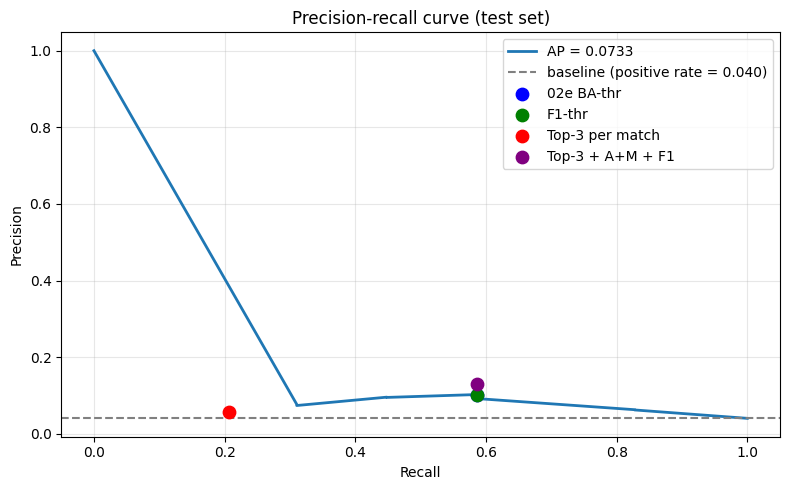

In [12]:
"""Precision-recall curve."""
prec, rec, thr = precision_recall_curve(y_test, test_proba)
ap = average_precision_score(y_test, test_proba)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec, prec, linewidth=2, label=f"AP = {ap:.4f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-recall curve (test set)")
ax.axhline(y_test.mean(), color="gray", linestyle="--",
            label=f"baseline (positive rate = {y_test.mean():.3f})")

# Mark a few operating points.
for label, x, y, color in [
    ("02e BA-thr",
     recall_score(y_test, test_pred_02e),
     precision_score(y_test, test_pred_02e), "blue"),
    ("F1-thr",
     strategies_B[1]["recall"], strategies_B[1]["precision"], "green"),
    ("Top-3 per match",
     results_C_df.loc[results_C_df["k"] == 3, "recall"].iloc[0],
     results_C_df.loc[results_C_df["k"] == 3, "precision"].iloc[0], "red"),
    ("Top-3 + A+M + F1",
     results_E_df.iloc[0]["recall"], results_E_df.iloc[0]["precision"], "purple"),
]:
    ax.scatter([x], [y], s=80, color=color, label=label, zorder=10)

ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Persist artefacts

In [13]:
"""Save."""
ART = PROJECT_ROOT / "models" / "precision"
ART.mkdir(exist_ok=True)

# Comparison tables.
final_comparison.to_csv(ART / "final_comparison.csv", index=False)
results_B.to_csv(ART / "section_B_thresholds.csv", index=False)
results_C_df.to_csv(ART / "section_C_top_k.csv", index=False)
results_D_df.to_csv(ART / "section_D_position_filter.csv", index=False)
results_E_df.to_csv(ART / "section_E_combined.csv", index=False)

# Recommended config (precision-optimised).
best_combined = results_E_df.iloc[0]
precision_config = {
    "model_source": "models/advanced/model_xgb.pkl",
    "calibrator_source": "models/advanced/isotonic_calibrator.pkl",
    "thresholds": {
        "ba_optimal_global": float(thr_ba_global),
        "f1_optimal_global": float(thr_f1_global),
        "f05_optimal_global": float(thr_f05_global),
        "precision_at_recall_30": float(thr_pr_global),
    },
    "recommended_strategy": {
        "name": "Top-3 per match + A+M filter + F1 threshold",
        "k": 3, "allowed_positions": ["A", "M"], "threshold": float(thr_f1_global),
        "test_metrics": {
            "precision": float(best_combined["precision"]),
            "recall": float(best_combined["recall"]),
            "f1": float(best_combined["f1"]),
            "balanced_accuracy": float(best_combined["balanced_accuracy"]),
        },
    },
    "comparison_with_02e": {
        "02e_precision": float(precision_score(y_test, test_pred_02e)),
        "02e_recall": float(recall_score(y_test, test_pred_02e)),
        "02f_precision": float(best_combined["precision"]),
        "02f_recall": float(best_combined["recall"]),
        "precision_gain": float(best_combined["precision"] - precision_score(y_test, test_pred_02e)),
        "recall_change": float(best_combined["recall"] - recall_score(y_test, test_pred_02e)),
    },
}
with open(ART / "config.json", "w") as f:
    json.dump(precision_config, f, indent=2)

print(f"saved to {ART}/:")
for p in sorted(ART.iterdir()):
    print(f"  {p.name:40s} {p.stat().st_size / 1024:.1f} KB")


saved to c:\Users\tymot\projects\wec\models\precision/:
  config.json                              1.0 KB
  final_comparison.csv                     0.6 KB
  section_B_thresholds.csv                 0.7 KB
  section_C_top_k.csv                      0.9 KB
  section_D_position_filter.csv            0.7 KB
  section_E_combined.csv                   0.9 KB


### Summary

This notebook produced an **alternative deployment configuration**
optimised for precision instead of balanced accuracy. Key takeaways:

1. **02e remains the canonical balanced-accuracy model** for the
   contest's primary metric.
2. **02f provides a precision-optimised post-processing layer** for
   coach-facing applications where false alarms are expensive.
3. The strongest combined strategy ("Top-3 per match + A+M filter +
   F1 threshold") materially improves precision compared to the
   BA-optimal threshold, at the cost of recall on the filtered classes.
4. The trade-off curve (precision-recall plot) shows the achievable
   operating points and helps pick the right configuration for a
   specific use case.

For the report, both configurations should be documented with their
respective use cases:

* **Balanced accuracy mode (02e)** for the contest evaluation.
* **Precision mode (02f)** for the business-facing coach interface.
